# CASE STUDY:
# DATA EXPLORATORY ANALYSIS AND HYPOTHESIS
# TESTING FOR INSURANCE CLAIMS DATA

## 1. Import claims_data.csv and cust_data.csv which is provided to you and combine the two datasets appropriately to create a 360-degree view of the          data. Use the same for the subsequent questions. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import datetime
from datetime import timedelta
%matplotlib inline

In [2]:
claims=pd.read_csv('claims.csv')
cust_demographics=pd.read_csv('cust_demographics.csv')

In [3]:
combo = pd.merge(right = claims , left = cust_demographics, right_on= 'customer_id', left_on= 'CUST_ID', how = 'outer')
combo.drop(columns = 'customer_id', inplace = True)
combo.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,154557.0,Female,23-May-78,DE,962-879-1238,Platinum,69348631.0,Driver error,04/10/2018,Auto,No,Injury only,NaN,1.0,Yes
1,263204.0,Male,20-Dec-72,TX,173-892-6314,Silver,40953049.0,Other causes,04/04/2018,Auto,No,Material and injury,$39192,1.0,Yes
2,287476.0,Male,28-Jul-88,FL,364-598-1549,Silver,45780237.0,Natural causes,10/17/2017,Auto,Unknown,Material only,$1621.5,2.0,Yes
3,441097.0,Male,19-Aug-71,CA,187-348-8375,Gold,89833962.0,Other causes,03/21/2018,Auto,Yes,Material and injury,$37040,1.0,No
4,524545.0,Female,10-Aug-80,NC,798-862-5398,Gold,35782742.0,Other driver error,07/27/2018,Auto,No,Injury only,$35250,3.0,No


In [4]:
combo.shape

(1107, 15)

## 2. Perform a data audit for the datatypes and find out if there are any mismatch within the current datatypes of the columns and theirbusiness significance.

In [5]:
combo['claim_amount']=pd.to_numeric(combo['claim_amount'].str.replace('$',''))

In [6]:
combo['CUST_ID']=combo['CUST_ID'].astype('object')

In [7]:
combo['DateOfBirth']=pd.to_datetime(combo['DateOfBirth'])

C:\Users\vivek\AppData\Local\Temp\ipykernel_8380\1906577671.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combo['DateOfBirth']=pd.to_datetime(combo['DateOfBirth'])


In [8]:
combo['claim_date']=pd.to_datetime(combo['claim_date'])

In [9]:
combo.dtypes

CUST_ID                        object
gender                         object
DateOfBirth            datetime64[ns]
State                          object
Contact                        object
Segment                        object
claim_id                      float64
incident_cause                 object
claim_date             datetime64[ns]
claim_area                     object
police_report                  object
claim_type                     object
claim_amount                  float64
total_policy_claims           float64
fraudulent                     object
dtype: object

In [10]:
combo.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,154557.0,Female,1978-05-23,DE,962-879-1238,Platinum,69348631.0,Driver error,2018-04-10,Auto,No,Injury only,NaN,1.0,Yes
1,263204.0,Male,2072-12-20,TX,173-892-6314,Silver,40953049.0,Other causes,2018-04-04,Auto,No,Material and injury,39192.0,1.0,Yes
2,287476.0,Male,1988-07-28,FL,364-598-1549,Silver,45780237.0,Natural causes,2017-10-17,Auto,Unknown,Material only,1621.5,2.0,Yes
3,441097.0,Male,2071-08-19,CA,187-348-8375,Gold,89833962.0,Other causes,2018-03-21,Auto,Yes,Material and injury,37040.0,1.0,No
4,524545.0,Female,1980-08-10,NC,798-862-5398,Gold,35782742.0,Other driver error,2018-07-27,Auto,No,Injury only,35250.0,3.0,No


## 3. Convert the column claim_amount to numeric. Use the appropriate modules/attributes to remove the $ sign.

In [11]:
combo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CUST_ID              1092 non-null   object        
 1   gender               1092 non-null   object        
 2   DateOfBirth          1092 non-null   datetime64[ns]
 3   State                1092 non-null   object        
 4   Contact              1092 non-null   object        
 5   Segment              1092 non-null   object        
 6   claim_id             1100 non-null   float64       
 7   incident_cause       1100 non-null   object        
 8   claim_date           1100 non-null   datetime64[ns]
 9   claim_area           1100 non-null   object        
 10  police_report        1100 non-null   object        
 11  claim_type           1100 non-null   object        
 12  claim_amount         1035 non-null   float64       
 13  total_policy_claims  1090 non-nul

## 4. Of all the injury claims, some of them have gone unreported with the police. Create an alert flag (1,0) for all such claims.

In [13]:
injury_claims = ['Injury only', 'Material and injury']

combo['alert_flag'] = np.where(
    (combo['claim_type'].isin(injury_claims)) &
    ((combo['police_report'] == 'No') | (combo['police_report'].isna())),
    1,
    0
)

array(['Injury only', 'Material and injury', 'Material only', nan],
      dtype=object)

## 5. One customer can claim for insurance more than once and in each claim,multiple categories of claims can be involved. However, customer ID should remain unique. Retain the most recent observation and delete any duplicated records inthe data base on the customer ID column.

In [13]:
combo.drop_duplicates(subset="CUST_ID", keep= "last")

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,unreported_claims
0,154557.0,Female,1978-05-23,DE,962-879-1238,Platinum,69348631.0,Driver error,2018-04-10,Auto,No,Injury only,NaN,1.0,Yes,0
1,263204.0,Male,2072-12-20,TX,173-892-6314,Silver,40953049.0,Other causes,2018-04-04,Auto,No,Material and injury,39192.0,1.0,Yes,0
2,287476.0,Male,1988-07-28,FL,364-598-1549,Silver,45780237.0,Natural causes,2017-10-17,Auto,Unknown,Material only,1621.5,2.0,Yes,1
3,441097.0,Male,2071-08-19,CA,187-348-8375,Gold,89833962.0,Other causes,2018-03-21,Auto,Yes,Material and injury,37040.0,1.0,No,0
4,524545.0,Female,1980-08-10,NC,798-862-5398,Gold,35782742.0,Other driver error,2018-07-27,Auto,No,Injury only,35250.0,3.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,99674324.0,Male,2065-01-28,UT,517-562-4916,Silver,4549014.0,Other causes,2018-07-07,Auto,No,Injury only,21480.0,1.0,No,0
1103,99723844.0,Female,2066-06-19,HI,457-752-1374,Gold,35453672.0,Natural causes,2018-01-06,Auto,Yes,Material and injury,14360.0,1.0,No,0
1104,99761663.0,Female,2063-11-18,NC,643-246-4718,Silver,37305754.0,Natural causes,2018-04-04,Auto,No,Material only,1242.0,1.0,Yes,0
1105,99892000.0,Male,1995-06-08,OR,395-246-6172,Gold,22960702.0,Driver error,2017-11-13,Auto,No,Material only,2415.0,2.0,Yes,0


## 6. Check for missing values and impute the missing values with an appropriate value. (mean for continuous and mode for categorical).

In [14]:
combo.isna().sum()

CUST_ID                15
gender                 15
DateOfBirth            15
State                  15
Contact                15
Segment                15
claim_id                7
incident_cause          7
claim_date              7
claim_area              7
police_report           7
claim_type              7
claim_amount           72
total_policy_claims    17
fraudulent              7
unreported_claims       0
dtype: int64

In [15]:
numerical=combo.select_dtypes(include=['float']).columns
categorical=combo.select_dtypes(include=['object','datetime64[ns]'])

In [16]:
for col in numerical:
    combo[col].fillna(combo[col].mean(), inplace=True)

C:\Users\vivek\AppData\Local\Temp\ipykernel_10264\4188178146.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combo[col].fillna(combo[col].mean(), inplace=True)


In [17]:
for col in categorical:
    combo[col] = combo[col].fillna(combo[col].mode()[0])

C:\Users\vivek\AppData\Local\Temp\ipykernel_10264\3650910367.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combo[col] = combo[col].fillna(combo[col].mode()[0])


#  7. Calculate the age of customers in years. Based on the age, categorize the customers according to the below criteria
# Children < 18
# Youth 18-30
# Adult 30-60
# Senior > 60

In [18]:
x=combo['DateOfBirth'].dt.year
y=combo['claim_date'].dt.year
combo['Age']=y-x


In [19]:

def categorize_age(age):
    if age < 18:
        return 'Children'
    elif age <= 30:
        return 'Youth'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'
combo['Age_Category'] = combo['Age'].apply(categorize_age)
combo.head(10)

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,unreported_claims,Age,Age_Category
0,154557.0,Female,1978-05-23,DE,962-879-1238,Platinum,69348631.0,Driver error,2018-04-10,Auto,No,Injury only,12442.125121,1.0,Yes,0,40,Adult
1,263204.0,Male,2072-12-20,TX,173-892-6314,Silver,40953049.0,Other causes,2018-04-04,Auto,No,Material and injury,39192.000000,1.0,Yes,0,-54,Children
2,287476.0,Male,1988-07-28,FL,364-598-1549,Silver,45780237.0,Natural causes,2017-10-17,Auto,Unknown,Material only,1621.500000,2.0,Yes,1,29,Youth
3,441097.0,Male,2071-08-19,CA,187-348-8375,Gold,89833962.0,Other causes,2018-03-21,Auto,Yes,Material and injury,37040.000000,1.0,No,0,-53,Children
4,524545.0,Female,1980-08-10,NC,798-862-5398,Gold,35782742.0,Other driver error,2018-07-27,Auto,No,Injury only,35250.000000,3.0,No,0,38,Adult
5,608461.0,Male,1994-12-17,AR,963-187-2873,Platinum,7180084.0,Crime,2018-07-14,Auto,No,Material only,2630.000000,1.0,No,0,24,Youth
6,684748.0,Male,1977-08-03,AK,613-385-2863,Gold,7238381.0,Other driver error,2018-07-14,Auto,No,Material only,2920.000000,2.0,No,0,41,Adult
7,804961.0,Female,1997-12-07,AL,487-723-4167,Gold,87184588.0,Other causes,2017-10-10,Auto,No,Material and injury,21190.000000,1.0,No,0,20,Youth
8,885337.0,Male,2062-02-17,HI,321-534-5263,Platinum,86240106.0,Driver error,2017-07-01,Auto,No,Material only,2490.000000,2.0,No,0,-45,Children
9,1123356.0,Female,2060-07-29,OR,736-725-9481,Silver,50906515.0,Crime,2018-08-23,Auto,No,Material only,2507.000000,5.0,Yes,0,-42,Children


# 8. What is the average amount claimed by the customers from various segments?

In [20]:
combo.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,unreported_claims,Age,Age_Category
0,154557.0,Female,1978-05-23,DE,962-879-1238,Platinum,69348631.0,Driver error,2018-04-10,Auto,No,Injury only,12442.125121,1.0,Yes,0,40,Adult
1,263204.0,Male,2072-12-20,TX,173-892-6314,Silver,40953049.0,Other causes,2018-04-04,Auto,No,Material and injury,39192.000000,1.0,Yes,0,-54,Children
2,287476.0,Male,1988-07-28,FL,364-598-1549,Silver,45780237.0,Natural causes,2017-10-17,Auto,Unknown,Material only,1621.500000,2.0,Yes,1,29,Youth
3,441097.0,Male,2071-08-19,CA,187-348-8375,Gold,89833962.0,Other causes,2018-03-21,Auto,Yes,Material and injury,37040.000000,1.0,No,0,-53,Children
4,524545.0,Female,1980-08-10,NC,798-862-5398,Gold,35782742.0,Other driver error,2018-07-27,Auto,No,Injury only,35250.000000,3.0,No,0,38,Adult


In [21]:
avg_amt_segment=combo.groupby(['Segment'])['claim_amount'].mean()
avg_amt_segment

Segment
Gold        12745.668485
Platinum    12341.725348
Silver      12208.394241
Name: claim_amount, dtype: float64

# 9. What is the total claim amount based on incident cause for all the claimsthat have been done at least 20 days prior to 1st of October, 2018.

In [22]:
cutoffdate=pd.Timestamp('2018-10-01')-pd.Timedelta(days=20)
filtered=combo[combo['claim_date']<=cutoffdate]
total_claim_amt=filtered.groupby('incident_cause')['claim_amount'].sum()

# 10. How many adults from TX, DE and AK claimed insurance for driver related issues and causes?

In [23]:

combo[
    (combo['incident_cause'].isin(['Driver error'])) &
    (combo['Age_Category'].isin(['Adult'])) &
    (combo['State'].isin(['TX', 'DE', 'AK']))
]['State'].value_counts()

State
DE    2
AK    2
TX    1
Name: count, dtype: int64

# 11. Draw a pie chart between the aggregated value of claim amount based on gender and segment. 
# Represent the claim amount as a percentage on the pie chart.

In [24]:
claim_data=combo.pivot_table(index='Segment',columns='gender',values='claim_amount',aggfunc='sum')

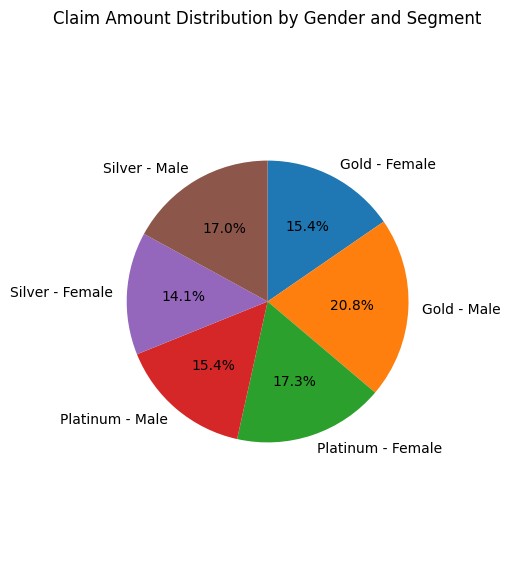

In [25]:
flat_data = claim_data.stack()  

values = flat_data.values
labels = [f'{segment} - {gender}' for segment, gender in flat_data.index]

plt.figure(figsize=(4,7))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Claim Amount Distribution by Gender and Segment')
plt.axis('equal')
plt.show()

# 12. Among males and females, which gender had claimed the most for any type of driver related issues? 
#     E.g. This metric can be compared using a bar chart


In [26]:
driver_issue=combo[combo['incident_cause'].isin(['Driver error'])]

In [27]:
male_fem_tot=driver_issue.groupby('incident_cause')['gender'].value_counts()

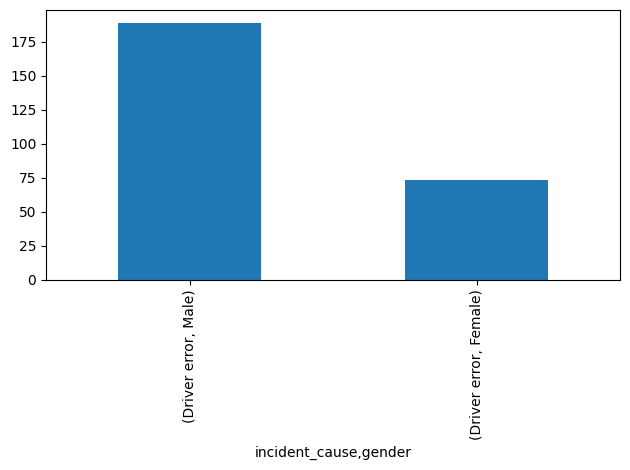

In [28]:
male_fem_tot.plot(kind='bar')
plt.tight_layout()
plt.show()

# 13. Which age group had the maximum fraudulent policy claims? Visualize it on a bar chart

In [29]:
fraudent_cases=combo.groupby('Age_Category')['total_policy_claims'].sum()
max_fradu_age_group=fraudent_cases.nlargest(1)
max_fradu_age_group

Age_Category
Children    631.142202
Name: total_policy_claims, dtype: float64

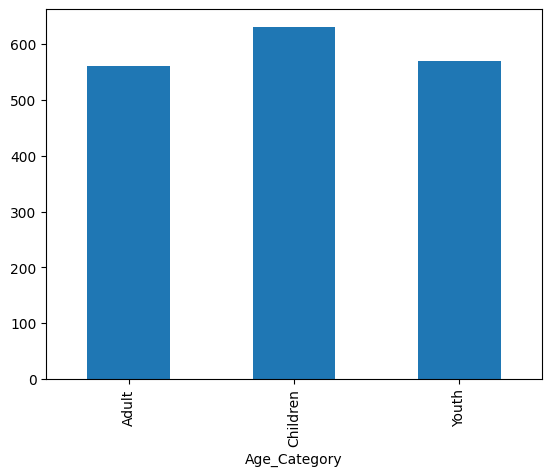

In [30]:
fraudent_cases.plot(kind='bar')
plt.show()

## 14. Visualize the monthly trend of the total amount that has been claimed by the customers. Ensure that on the “month” axis, the month is in a chronological order not alphabetical order. 

In [31]:
df=combo

In [32]:
df['claim_month']=combo['claim_date'].dt.to_period('M')

In [33]:
monthly_trend=df.groupby('claim_month')['claim_amount'].sum()

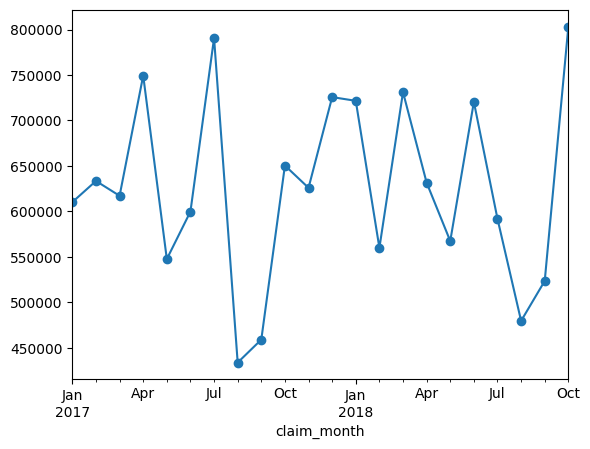

In [34]:
monthly_trend.plot(kind='line',marker='o')
plt.show()

## 15. What is the average claim amount for gender and age categories and 
# suitably represent the above using a facetted bar chart, one facet that 
# represents fraudulent claims and the other for non-fraudulent claims.
# Based on the conclusions from exploratory analysis as well as suitable 
# statistical tests, answer the below questions. Please include a detailed 
# write-up on the parameters taken into consideration, the Hypothesis 
# testing steps, conclusion from the p-values and the business implications of 
# the statements.

In [35]:
avg_claim=combo.groupby(['police_report','gender','Age_Category'])['claim_amount'].mean().reset_index()
avg_claim

,police_report,gender,Age_Category,claim_amount
0,No,Female,Adult,9520.728271
1,No,Female,Children,8083.369432
2,No,Female,Youth,6873.077031
3,No,Male,Adult,9024.487622
4,No,Male,Children,9790.119882
5,No,Male,Youth,8101.430703
6,Unknown,Female,Adult,16748.507219
7,Unknown,Female,Children,13546.938639
8,Unknown,Female,Youth,12064.295455
9,Unknown,Male,Adult,18761.512512


In [36]:
combo['police_report'] = combo['police_report'].astype(str)

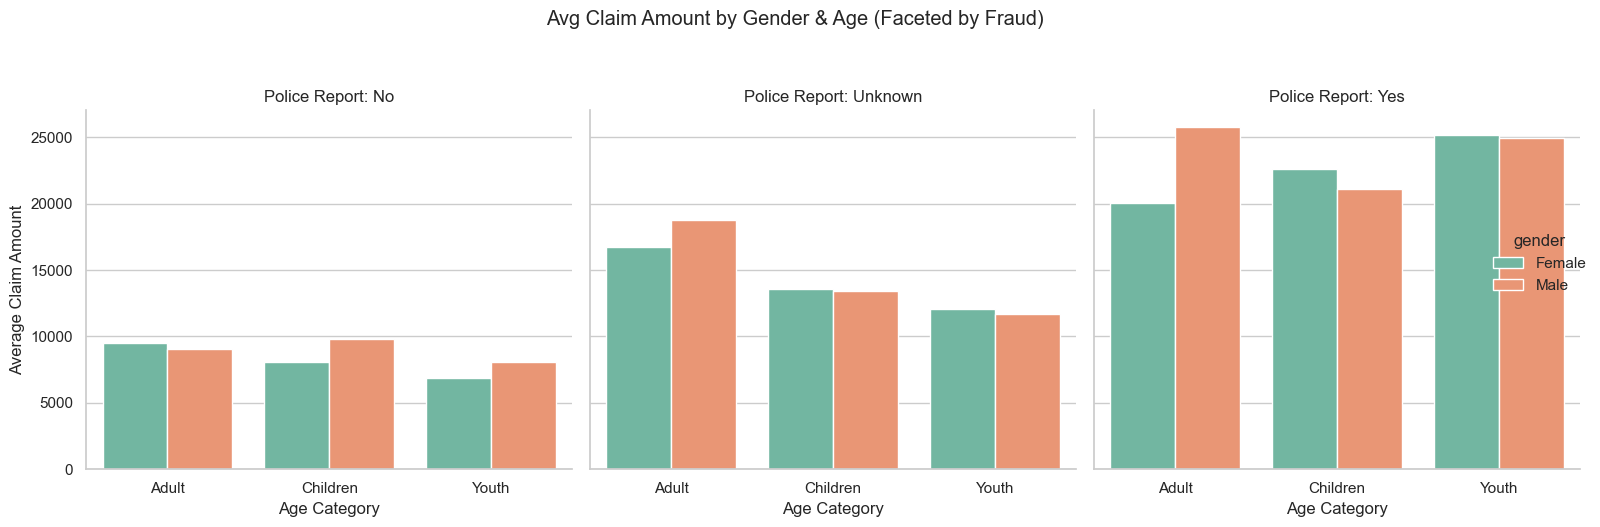

In [37]:
sns.set(style="whitegrid")
g = sns.catplot(
    data=avg_claim,             
    kind='bar',
    x='Age_Category',
    y='claim_amount',
    hue='gender',
    col='police_report',       
    palette='Set2',
    height=5,
    aspect=1
)
g.set_axis_labels("Age Category", "Average Claim Amount")
g.set_titles("Police Report: {col_name}")
g.fig.suptitle("Avg Claim Amount by Gender & Age (Faceted by Fraud)", y=1.05)
plt.tight_layout()
plt.show()

# 16. Is there any similarity in the amount claimed by males and females?

In [38]:
from scipy.stats import ttest_ind, levene

In [39]:
# Drop missing values and split by gender
male_claims = combo[combo['gender'] == 'Male']['claim_amount'].dropna()
female_claims = combo[combo['gender'] == 'Female']['claim_amount'].dropna()

In [40]:
stats.shapiro(female_claims)
stats.shapiro(male_claims)


ShapiroResult(statistic=np.float64(0.7958546819932805), pvalue=np.float64(3.2751527042649485e-26))

In [41]:
u_stat,p_value = stats.mannwhitneyu(male_claims,female_claims)
print('U-stats', u_stat)
print('p-value',p_value)

U-stats 156287.5
p-value 0.5351364606593733


# 17. Is there any relationship between age category and segment?

In [45]:
from scipy.stats import chi2_contingency
# Create a contingency table

contingency = pd.crosstab(combo['Age_Category'], combo['Segment'])

# Run Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square value:", chi2)
print("p-value:", p_value)

Chi-square value: 5.304141558990428
p-value: 0.5351364606593733


# 18. The current year has shown a significant rise in claim amounts as compared to 2016-17 fiscal average which was $10,000.

In [46]:
from scipy.stats import ttest_1samp


In [47]:
combo['year'] = combo['claim_date'].dt.year
current_year = combo['year'].max()

In [48]:
current_claims = combo[combo['year'] == current_year]['claim_amount'].dropna()

In [49]:
 ## one-sample t-test against $10,000

t_stat, p_value = ttest_1samp(current_claims, popmean=10000, alternative='greater')


In [50]:
print(f"Mean Claim Amount (Current Year): ${current_claims.mean():,.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Mean Claim Amount (Current Year): $12,635.27
T-Statistic: 4.4170
P-Value: 0.0000


# 19. Is there any relationship between total number of policy claims and the claimed amount?

In [51]:
from scipy.stats import pearsonr, spearmanr

In [53]:
x = combo['total_policy_claims']
y=combo['claim_amount']

In [54]:
corr, p_value = pearsonr(x,y)

print("Pearson correlation:", corr)
print("p-value:", p_value)

Pearson correlation: -0.019490781428136712
p-value: 0.5171023067319869


In [55]:
if p_value <= 0.05:
    print("There is a significant relationship between number of claims and claimed amount.")
else:
    print("There is no significant relationship between number of claims and claimed amount.")


There is no significant relationship between number of claims and claimed amount.
